In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Athelete.csv')

print(df.shape)
print(df.head())


(3111, 28)
              Athlete        Date Day.of.Week   RHR    HRV  Recovery  \
0  Athlete 1 Bergdorf  01-01-2022         NaN   NaN    NaN       NaN   
1  Athlete 1 Bergdorf  01-10-2022      Monday  48.0  120.0      58.0   
2  Athlete 1 Bergdorf  01-11-2022         NaN   NaN    NaN       NaN   
3  Athlete 1 Bergdorf  01-12-2022         NaN   NaN    NaN       NaN   
4  Athlete 1 Bergdorf   1/13/2022    Thursday  53.0  121.0      61.0   

   Sleep.Score  Hours.in.Bed  Hours.of.Sleep  Sleep.Need  ...  Awake..hours.  \
0          NaN           NaN             NaN         NaN  ...            NaN   
1         51.0          6.36            5.62       11.02  ...           0.74   
2          NaN           NaN             NaN         NaN  ...            NaN   
3          NaN           NaN             NaN         NaN  ...            NaN   
4         55.0          6.25            5.56       10.15  ...           0.70   

   Sleep.Debt..hours.  Sleep.Consistency  Respiratory.Rate  \
0            

In [5]:
print(df.describe())
print(df.info())


               RHR          HRV     Recovery  Sleep.Score  Hours.in.Bed  \
count  1981.000000  1981.000000  1981.000000  1981.000000   1981.000000   
mean     59.693084    84.065623    59.546189    76.393236      7.780843   
std       9.003574    36.105314    22.664673    18.553590      1.927197   
min      39.000000    14.000000     1.000000    10.000000      1.050000   
25%      53.000000    56.000000    43.000000    64.000000      6.580000   
50%      58.000000    79.000000    61.000000    78.000000      7.800000   
75%      65.000000   110.000000    77.000000    92.000000      8.960000   
max     120.000000   188.000000    99.000000   100.000000     17.130000   

       Hours.of.Sleep   Sleep.Need  Sleep.Efficiency....  Wake.Periods  \
count     1981.000000  1981.000000           1981.000000   1621.000000   
mean         6.890545     8.910611             88.865724     14.870450   
std          1.652425     1.117639              6.296796      6.613342   
min          0.820000     1.

In [6]:
for column in df.columns:
    print(f"Column '{column}': {df[column].isna().sum()} null values")

Column 'Athlete': 0 null values
Column 'Date': 0 null values
Column 'Day.of.Week': 1124 null values
Column 'RHR': 1130 null values
Column 'HRV': 1130 null values
Column 'Recovery': 1130 null values
Column 'Sleep.Score': 1130 null values
Column 'Hours.in.Bed': 1130 null values
Column 'Hours.of.Sleep': 1130 null values
Column 'Sleep.Need': 1130 null values
Column 'Sleep.Efficiency....': 1130 null values
Column 'Wake.Periods': 1490 null values
Column 'Sleep.Disturbances': 1130 null values
Column 'Latency..min.': 1130 null values
Column 'Cycles': 1130 null values
Column 'REM.Sleep..hours.': 1130 null values
Column 'Deep.Sleep..hours.': 1130 null values
Column 'Light.Sleep..hours.': 1130 null values
Column 'Awake..hours.': 1130 null values
Column 'Sleep.Debt..hours.': 1130 null values
Column 'Sleep.Consistency': 1401 null values
Column 'Respiratory.Rate': 1134 null values
Column 'Total.Cycle.Sleep.Time..hours.': 1130 null values
Column 'REM.Percentage': 1130 null values
Column 'Deep.Sleep.P

In [7]:
df = df.dropna(how='all')
df.shape

(3111, 28)

In [8]:
for column in df.columns:
      if df[column].dtype == 'object':
        df.drop(column, axis=1, inplace=True)

print(df.shape)

(3111, 25)


In [9]:
df.to_csv('cleaned_data_Athelete.csv', index=False)

In [35]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),max_iter=15, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


df_imputed.to_csv('Athelete_imputed.csv', index=False)

print(df_imputed.shape)

print(df_imputed.head())

df_imputed.info()

(3111, 25)
     RHR     HRV  Recovery  Sleep.Score  Hours.in.Bed  Hours.of.Sleep  \
0  59.84  102.15     73.82        82.73        8.0556          7.2672   
1  48.00  120.00     58.00        51.00        6.3600          5.6200   
2  59.84  102.15     73.82        82.73        8.0556          7.2672   
3  59.84  102.15     73.82        82.73        8.0556          7.2672   
4  53.00  121.00     61.00        55.00        6.2500          5.5600   

   Sleep.Need  Sleep.Efficiency....  Wake.Periods  Sleep.Disturbances  ...  \
0      8.9416                 89.98         16.48               15.09  ...   
1     11.0200                 88.00          7.00                6.00  ...   
2      8.9416                 89.98         16.48               15.09  ...   
3      8.9416                 89.98         16.48               15.09  ...   
4     10.1500                 89.00          8.00                7.00  ...   

   Awake..hours.  Sleep.Debt..hours.  Sleep.Consistency  Respiratory.Rate  \
0   

c:\Users\smart\Downloads\test\sort_venv\lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


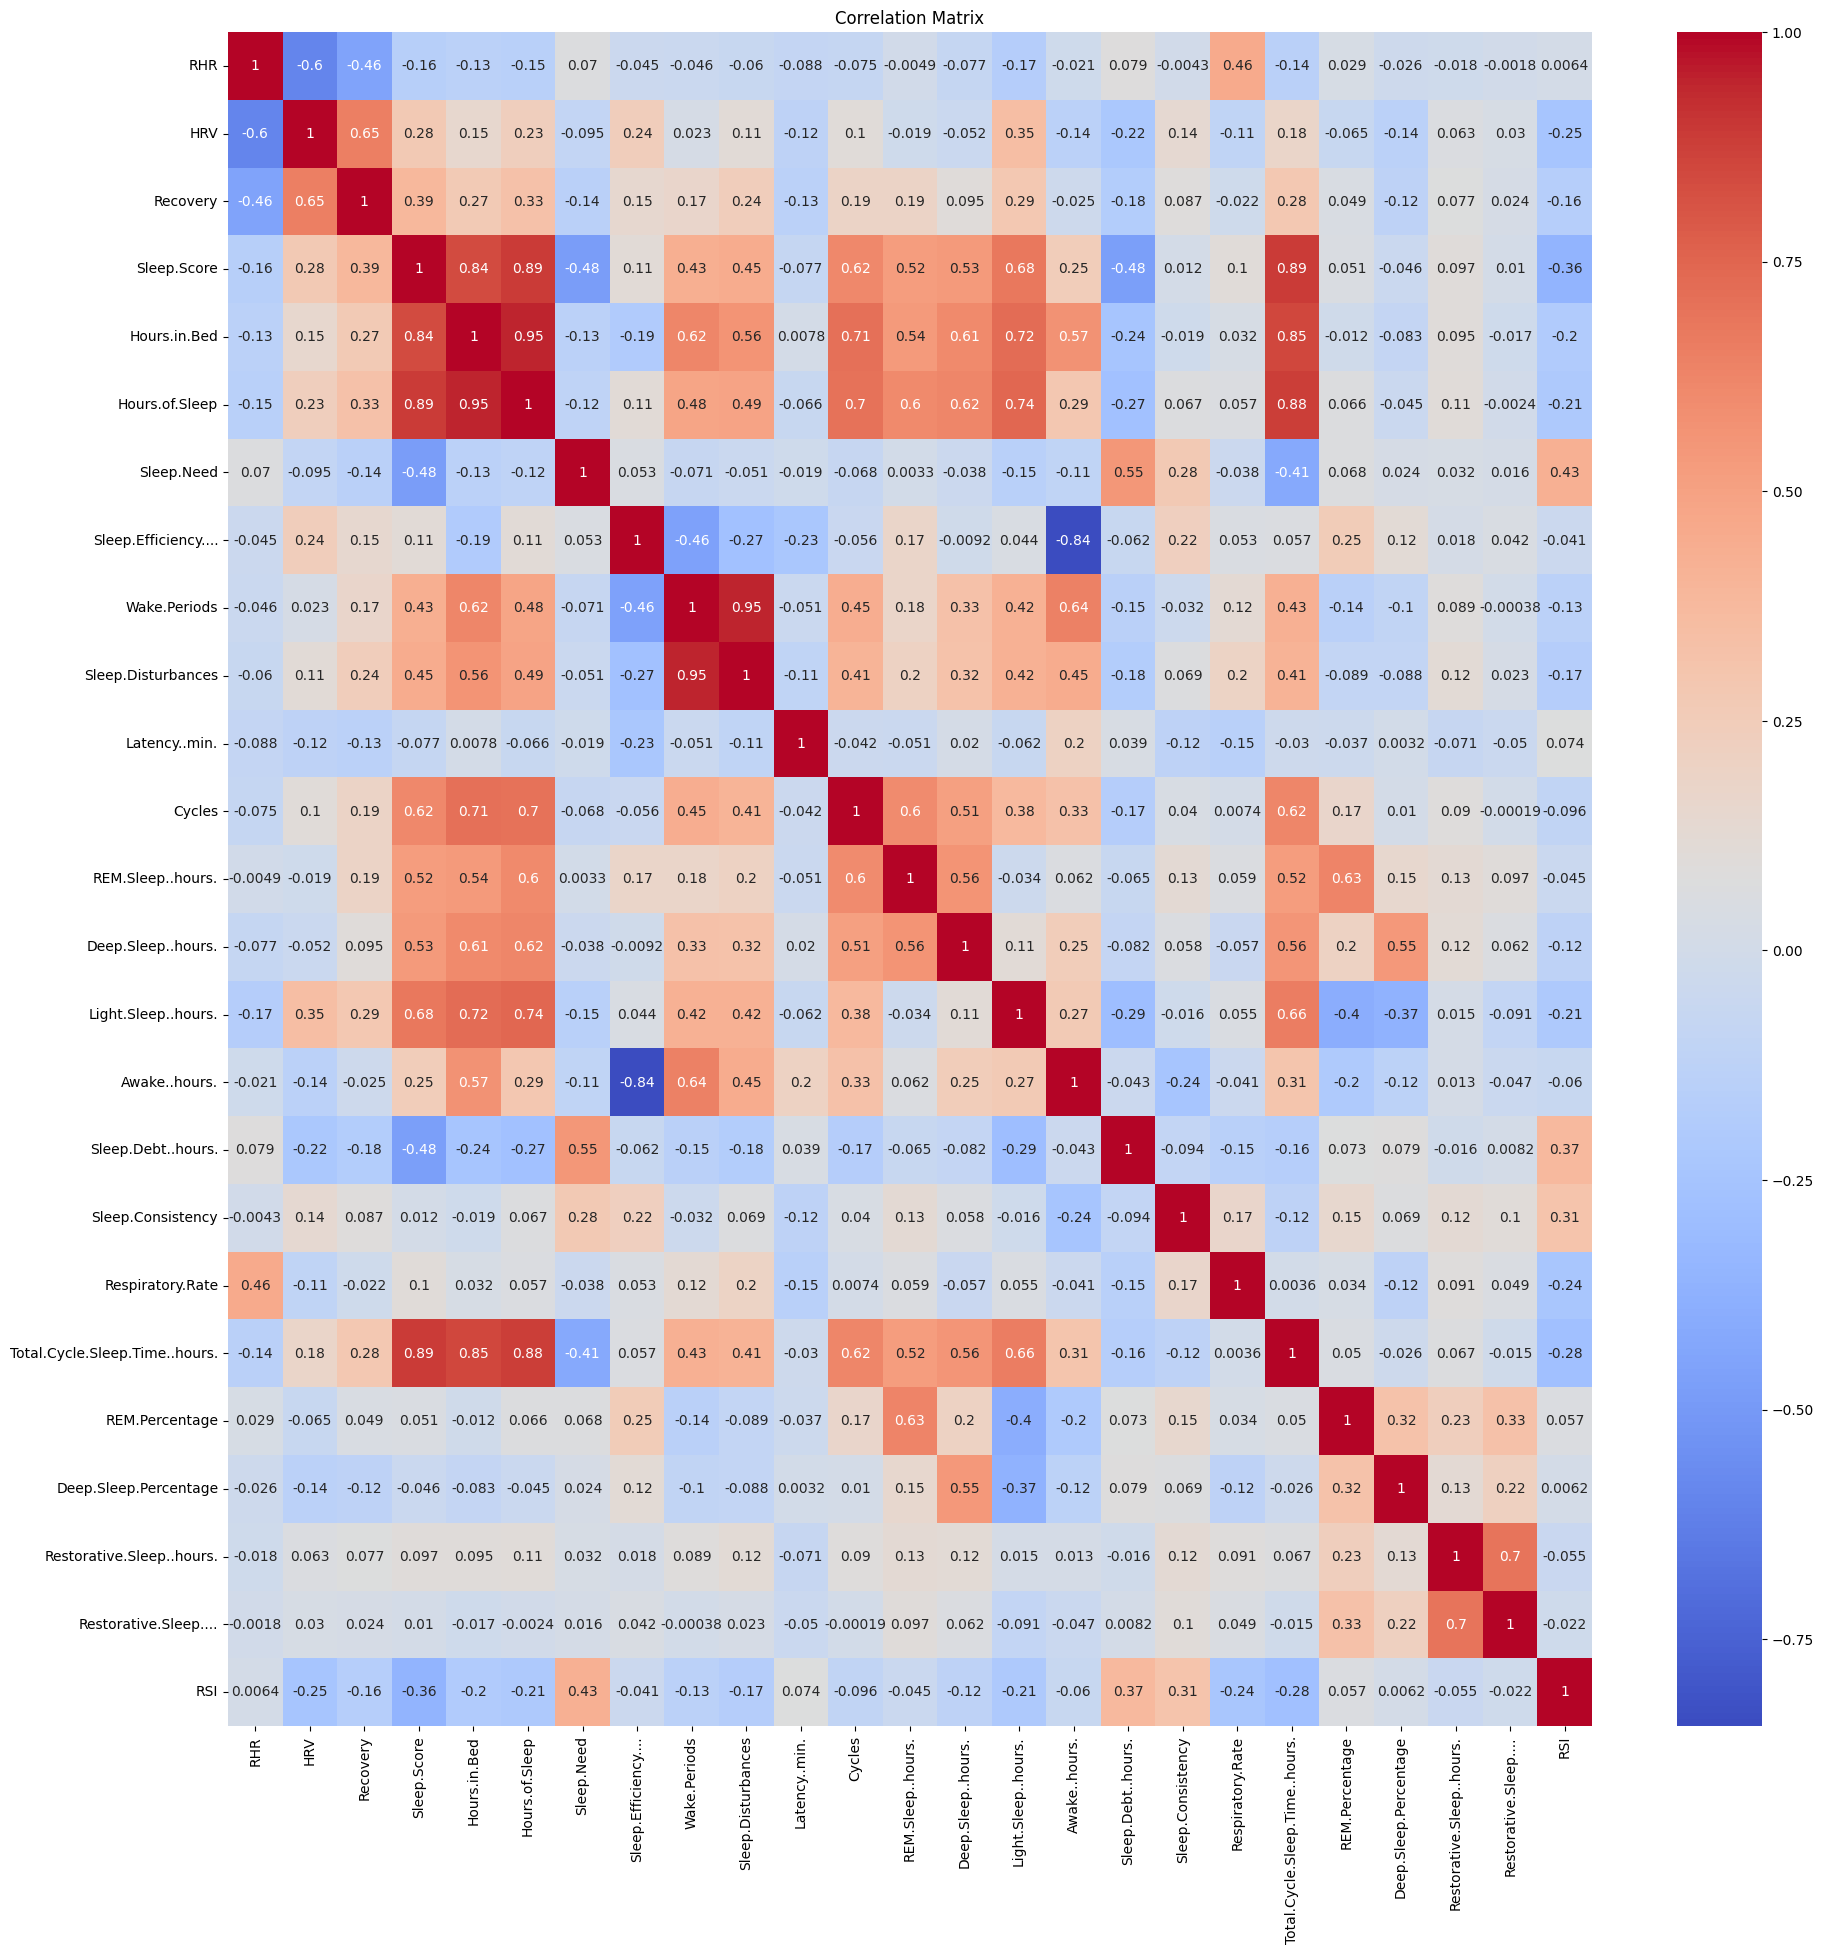

In [36]:
import seaborn as sns

fig = plt.figure(figsize=(22,22))
corr_matrix = df_imputed.corr()
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print(df_scaled.shape)

print(df_scaled.head())

df_scaled.to_csv('Athelete_scaled.csv', index=False)


(3111, 25)
        RHR       HRV  Recovery  Sleep.Score  Hours.in.Bed  Hours.of.Sleep  \
0  0.257284  0.506609  0.743061     0.808111      0.435672        0.560626   
1  0.111111  0.609195  0.581633     0.455556      0.330224        0.417391   
2  0.257284  0.506609  0.743061     0.808111      0.435672        0.560626   
3  0.257284  0.506609  0.743061     0.808111      0.435672        0.560626   
4  0.172840  0.614943  0.612245     0.500000      0.323383        0.412174   

   Sleep.Need  Sleep.Efficiency....  Wake.Periods  Sleep.Disturbances  ...  \
0    0.701692              0.880714      0.268148            0.328043  ...   
1    0.890810              0.857143      0.092593            0.130435  ...   
2    0.701692              0.880714      0.268148            0.328043  ...   
3    0.701692              0.880714      0.268148            0.328043  ...   
4    0.811647              0.869048      0.111111            0.152174  ...   

   Awake..hours.  Sleep.Debt..hours.  Sleep.Consist

In [38]:
threshold = 0.1
correlation_with_target = corr_matrix['RSI'].sort_values(ascending=False)
selected_features = correlation_with_target[abs(correlation_with_target)>=threshold].index
df_reduced = df_scaled[selected_features]
print(df_reduced.shape)
print(df_reduced.head())

(3111, 15)
        RSI  Sleep.Need  Sleep.Debt..hours.  Sleep.Consistency  \
0  0.359574    0.701692            0.217241           0.771848   
1  0.276596    0.890810            0.922414           0.581848   
2  0.359574    0.701692            0.217241           0.771848   
3  0.359574    0.701692            0.217241           0.771848   
4  0.332128    0.811647            0.543103           0.391304   

   Deep.Sleep..hours.  Wake.Periods  Recovery  Sleep.Disturbances  \
0            0.459377      0.268148  0.743061            0.328043   
1            0.465574      0.092593  0.581633            0.130435   
2            0.459377      0.268148  0.743061            0.328043   
3            0.459377      0.268148  0.743061            0.328043   
4            0.177049      0.111111  0.612245            0.152174   

   Hours.in.Bed  Light.Sleep..hours.  Hours.of.Sleep  Respiratory.Rate  \
0      0.435672             0.370577        0.560626          0.666153   
1      0.330224             0

In [39]:
df_reduced.to_csv('Athelete_reduced.csv',index=False)

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_reduced.drop(columns=["RSI"])
y = df_reduced["RSI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 0.04
Mean Squared Error: 0.00
R2 Score: 0.48


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_reduced.drop(columns=["RSI"])
y = df_reduced["RSI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 0.02
Mean Squared Error: 0.00
R2 Score: 0.81


In [42]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)

print(f"XGBoost R2 Score: {r2:.2f}")

XGBoost R2 Score: 0.83
